In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx

In [2]:
A = pd.read_pickle("data/indv_hashtag_simulations.pkl", compression="bz2")

In [3]:
P = A.drop_duplicates("hash2").copy()

In [4]:
%%time
def get_set_up(p):
    adj, inf_s, deg = p
#     overlap  = ( (adj * inf_s).sum(axis=1) != deg ).sum()
    overlap  = (( (adj * inf_s).sum(axis=1) != deg )*inf_s).sum() # those who are infected and lie on the frontier
    vax_count = inf_s.sum()
    ht2_count = ((inf_s == 0).sum() + overlap)
    vax_div_ab = overlap / vax_count 
    h2_div_ab  = overlap / ht2_count
    return overlap, vax_count, ht2_count, vax_div_ab, h2_div_ab 

P["overlap"] = P.params.apply(get_set_up)

CPU times: user 2.12 s, sys: 1.49 s, total: 3.61 s
Wall time: 4.53 s


In [5]:
def get_network(adj):
    G = nx.from_numpy_array(adj)
    return nx.radius(G)

In [6]:
%%time
A["ts_max"]     = A.ts_dorm.apply(lambda x: x[-1])
A["ts_midstep"] = A.ts_dorm.apply(lambda x: np.searchsorted(x, (x[-1]+x[0])/2, side='right'))
A["ts_gain"]    = A.ts_dorm.apply(lambda x: x[-1] - x[0])

CPU times: user 51.2 ms, sys: 20.9 ms, total: 72 ms
Wall time: 86.3 ms


In [7]:
P["vax_overlap"] = P.overlap.apply(lambda x: x[3])
P["ht2_overlap"] = P.overlap.apply(lambda x: x[4])
P["viable_depth"] = P.overlap.apply(lambda x: x[2] - x[0]) #ht2 - overlap

In [8]:
def get_num_CC(p,graph="full"):
    adj, inf_s, deg = p
    G = nx.from_numpy_array(adj)
    
    frontier  = (( (adj * inf_s).sum(axis=1) != deg )*inf_s) # those who are infected and lie on the frontier
    hash2_ids =  ~p[1]
    if graph == "full":
        return len(list( nx.connected_components(G) ))
    else:
        GG = G.subgraph(np.argwhere(hash2_ids + frontier ).squeeze())
        return len(list( nx.connected_components(GG) ))


In [9]:
%%time
P["num_CC_full"] = P.params.apply(lambda p: get_num_CC(p))

CPU times: user 15.4 s, sys: 1.57 s, total: 16.9 s
Wall time: 18.1 s


In [10]:
%%time
P["num_CC_hashgraph"] = P.params.apply(lambda p: get_num_CC(p,"sub"))

CPU times: user 15.2 s, sys: 1.52 s, total: 16.7 s
Wall time: 17.6 s


In [11]:
%time
P["density"] = P.params.apply(lambda x: nx.density( nx.from_numpy_array(x[0])))

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.29 µs


In [ ]:
P

In [12]:
AA = A.merge(P[["hash2","vax_overlap","ht2_overlap","density",
                "viable_depth", "num_CC_full", "num_CC_hashgraph"]],
             left_on="hash2", right_on="hash2")
AA["perc_gain"] = AA.ts_gain / (AA.viable_depth+1)
AA = AA[AA.ht2_overlap != 1]

In [14]:
AA['q_vax'] = pd.qcut(AA['vax_overlap'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
AA['q_ht2'] = pd.qcut(AA['ht2_overlap'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

AA['q_CC'] = pd.qcut(AA['num_CC_hashgraph'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
AA['q_dense'] = pd.qcut(AA['density'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

Text(0.5, 0, 'Metric Quantile')

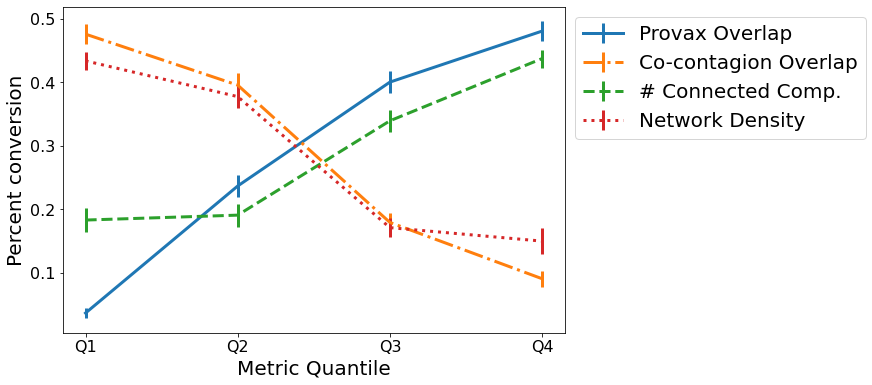

In [16]:
plt.figure(figsize=(9,6))

mu  = AA.groupby("q_vax")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_vax")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_vax, mu.perc_gain, yerr=mu.se,linewidth=3, label = "Provax Overlap")

mu  = AA.groupby("q_ht2")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_ht2")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_ht2, mu.perc_gain, yerr=mu.se,linewidth=3, linestyle="-.", label = "Co-contagion Overlap")

plt.legend(fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Metric Quantile", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)


mu  = AA.groupby("q_CC")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_CC")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_CC, mu.perc_gain, yerr=mu.se,linewidth=3, linestyle="--", label = "# Connected Comp.")

mu  = AA.groupby("q_dense")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_dense")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_dense, mu.perc_gain, yerr=mu.se,linewidth=3, linestyle=":", label = "Network Density")

plt.legend(fontsize=20,loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Metric Quantile", fontsize=20)

# plt.savefig("figures/conversion_yield.png", bbox_inches="tight")

In [25]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
mu  = AA.groupby("q_vax")["perc_gain"]

In [18]:
["q_vax", "q_ht2", "q_CC", "q_dense"]

['q_vax', 'q_ht2', 'q_CC', 'q_dense']

In [26]:
for c in ["q_vax", "q_ht2", "q_CC", "q_dense"]:
    print(c)
    groups = [AA[AA[c] == f"Q{i}"]["perc_gain"].values for i in range(1,5)]

    group1, group2, group3, group4 = groups

    f_stat, p_value = stats.f_oneway(group1, group2, group3, group4)
    print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4g}")

    # === Tukey's HSD ===
    # 1. Combine into one DataFrame
    df = pd.DataFrame({
        "value": np.concatenate([group1, group2, group3, group4]),
        "group": (["Q1"]*len(group1) + ["Q2"]*len(group2) + ["Q3"]*len(group3) + ["Q4"]*len(group4))
    })

    # 2. Run Tukey's HSD
    tukey = pairwise_tukeyhsd(endog=df["value"], groups=df["group"], alpha=0.05)
    print(tukey)

q_vax
ANOVA F-statistic: 1617.4271, p-value: 0
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
    Q1     Q2   0.2001   0.0 0.1823 0.2179   True
    Q1     Q3   0.3637   0.0 0.3462 0.3813   True
    Q1     Q4   0.4441   0.0 0.4263 0.4619   True
    Q2     Q3   0.1636   0.0 0.1458 0.1815   True
    Q2     Q4    0.244   0.0 0.2259 0.2621   True
    Q3     Q4   0.0804   0.0 0.0625 0.0982   True
-------------------------------------------------
q_ht2
ANOVA F-statistic: 1214.8601, p-value: 0
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    Q1     Q2  -0.0803   0.0 -0.0992 -0.0615   True
    Q1     Q3  -0.2966   0.0 -0.3151 -0.2781   True
    Q1     Q4  -0.3852   0.0 -0.4041 -0.3664   True
    Q2     Q3  -0.2162   0.0  -0.235 -0.1974   True
    Q2     Q4  -0.3049   0.0  -0.324 -0.